# Spark ETL Pipeline: HDFS to S3

## Objective
The objective of this notebook is to perform the transformation stage of the ETL pipeline using PySpark.  
The transactional ATM data imported into HDFS using Sqoop is read into Spark, transformed into
dimension and fact tables based on the target data model, and finally loaded into an Amazon S3 bucket
for downstream analytics using Amazon Redshift.

## Key Steps
- Read raw ATM transaction data from HDFS
- Apply a predefined schema using StructType
- Create dimension tables (ATM, Location, Date, Card Type)
- Create a transaction fact table
- Write the transformed data to Amazon S3 in Parquet format

## Define Input Schema

To avoid schema inference issues and ensure type consistency, an explicit schema is defined
based on the provided data dictionary for the SRC_ATM_TRANS table.

In [ ]:
from pyspark.sql.types import *

atm_schema = StructType([
    StructField("year", IntegerType(), True),
    StructField("month", StringType(), True),
    StructField("day", IntegerType(), True),
    StructField("weekday", StringType(), True),
    StructField("hour", IntegerType(), True),
    StructField("atm_status", StringType(), True),
    StructField("atm_id", StringType(), True),
    StructField("atm_manufacturer", StringType(), True),
    StructField("atm_location", StringType(), True),
    StructField("atm_street_name", StringType(), True),
    StructField("atm_street_number", IntegerType(), True),
    StructField("atm_zipcode", IntegerType(), True),
    StructField("atm_lat", DoubleType(), True),
    StructField("atm_lon", DoubleType(), True),
    StructField("currency", StringType(), True),
    StructField("card_type", StringType(), True),
    StructField("transaction_amount", IntegerType(), True),
    StructField("service", StringType(), True),
    StructField("message_code", StringType(), True),
    StructField("message_text", StringType(), True),
    StructField("weather_lat", DoubleType(), True),
    StructField("weather_lon", DoubleType(), True),
    StructField("weather_city_id", IntegerType(), True),
    StructField("weather_city_name", StringType(), True),
    StructField("temp", DoubleType(), True),
    StructField("pressure", IntegerType(), True),
    StructField("humidity", IntegerType(), True),
    StructField("wind_speed", IntegerType(), True),
    StructField("wind_deg", IntegerType(), True),
    StructField("rain_3h", DoubleType(), True),
    StructField("clouds_all", IntegerType(), True),
    StructField("weather_id", IntegerType(), True),
    StructField("weather_main", StringType(), True),
    StructField("weather_description", StringType(), True)
])

## Read Raw Data from HDFS

The ATM transactional data previously ingested using Sqoop is stored in HDFS.
The data is now read into Spark using the predefined schema.

In [ ]:
atm_df = spark.read \
    .schema(atm_schema) \
    .csv("hdfs:///user/hadoop/atm_raw")

atm_df.count()
atm_df.show(5, truncate=False)

## Create DIM_LOCATION

The location dimension contains normalized ATM location information and is referenced
by both the ATM and fact tables.

In [ ]:
dim_location = atm_df.select(
    col("atm_location").alias("location"),
    col("atm_street_name"),
    col("atm_street_number"),
    col("atm_zipcode"),
    col("atm_lat").alias("lat"),
    col("atm_lon").alias("lon") ).dropDuplicates() \  
    .withColumn("location_id", monotonically_increasing_id()
    )

dim_location.show(5)

## Create DIM_ATM

The ATM dimension is created at a grain of one record per ATM ID.


In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

atm_window = Window.partitionBy("atm_id") \
                   .orderBy("year", "month", "day", "hour")

dim_atm_base = atm_df.select(
... "atm_id",
... "atm_manufacturer",
... "atm_location" ).dropDuplicates(["atm_id"])

atm_location_lookup = dim_location \
    .select("location_id", "location") \
    .dropDuplicates(["location"])

dim_atm = dim_atm_base \
    .join(
        atm_location_lookup,
        dim_atm_base.atm_location == atm_location_lookup.location,
        "left"
    ) \
    .select(
        col("atm_id").cast("int"),
        col("atm_id").alias("atm_number"),
        col("atm_manufacturer"),
        col("location_id").alias("atm_location_id")
    )

## Create DIM_DATE

The date dimension is created using year, month, day, hour, and weekday fields.


In [ ]:
from pyspark.sql.functions import to_timestamp, concat_ws, lit

dim_date = atm_df.select(
    concat_ws(" ",
        col("year"),
        col("month"),
        col("day"),
        col("hour")
    ).alias("full_date_time"),
    "year", "month", "day", "hour", "weekday" ).dropDuplicates() \  
    .withColumn("date_id", monotonically_increasing_id())
    
dim_date.show(5)

## Create DIM_CARD_TYPE

The card type dimension contains unique values of card types used in ATM transactions.

In [ ]:
dim_card_type = atm_df.select("card_type") \
    .dropDuplicates() \
    .withColumn("card_type_id", monotonically_increasing_id())

dim_card_type.show(5)

## Create FACT_ATM_TRANS

The fact table is created by joining the transactional data with all dimension tables
using the appropriate surrogate keys.

In [ ]:
weather_location_lookup = dim_location \
    .select("location_id", "location", "lat", "lon") \
    .dropDuplicates(["lat", "lon"])

fact_atm_trans = atm_df \
    .join(dim_atm, "atm_id") \
    .join(dim_card_type, "card_type") \
    .join(dim_date, ["year", "month", "day", "hour", "weekday"]) \
    .join(weather_location_lookup,(atm_df.weather_lat == weather_location_lookup.lat) & (atm_df.weather_lon == weather_location_lookup.lon),"left") \
    .select(
        monotonically_increasing_id().alias("trans_id"),
        col("atm_id").cast("int"),
        col("location_id").alias("weather_loc_id"),
        col("date_id"),
        col("card_type_id"),
        col("atm_status"),
        col("currency"),
        col("service"),
        col("transaction_amount"),
        col("message_code"),
        col("message_text"),
        col("rain_3h"),
        col("clouds_all"),
        col("weather_id"),
        col("weather_main"),
        col("weather_description")
    )


fact_atm_trans.show(5)

## Compare to the Validation Document

Each table is counted to compare with the Validation Document

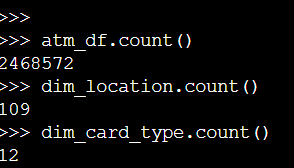
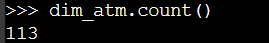
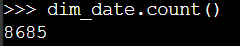

## Load Dimension and Fact Tables to Amazon S3

All transformed tables are written to Amazon S3 in Parquet format for efficient loading into Redshift.

In [ ]:
dim_location.write.mode("overwrite").parquet("s3://mike-upgrad-etl-project/dim_location/")
dim_atm.write.mode("overwrite").parquet("s3://mike-upgrad-etl-project/dim_atm/")
dim_date.write.mode("overwrite").parquet("s3://mike-upgrad-etl-project/dim_date/")
dim_card_type.write.mode("overwrite").parquet("s3://mike-upgrad-etl-project/dim_card_type/")
fact_atm_trans.write.mode("overwrite").parquet("s3://mike-upgrad-etl-project/fact_atm_trans/")